In [1]:
%load_ext autoreload
%autoreload 2
    
import numpy as np
import torch
import matplotlib.pyplot as plt

from torch.utils.data import TensorDataset
from torch_geometric.loader import DataLoader
from torch_geometric.data import Data
from sklearn.model_selection import train_test_split

import gnn_edges

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:

graphs_list = torch.load('../data_collection/graphs_with_edges.pt', weights_only=False)

graphs_train, graphs_val = train_test_split(
    graphs_list,
    test_size=0.10,
    random_state=42
)


train_loader = DataLoader(
    graphs_train, 
    batch_size=300,   
    shuffle=True
)

val_loader = DataLoader(
    graphs_val, 
    batch_size=300,   
    shuffle=True
)

device = torch.device("cpu")

In [33]:
epochs = 100
model = gnn_edges.GatedEdgeConv(128, 64, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [07:21<00:00,  4.41s/it]


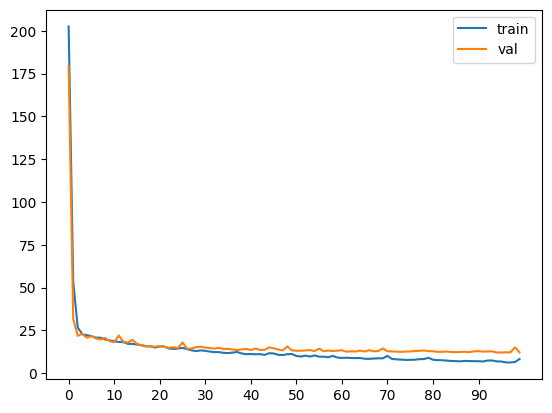

R² Train Score: 0.867
Train RMSE:     ±0.365
Train MAE:      ±0.258
R² Val Score: 0.637
Val RMSE:     ±0.601
Val MAE:      ±0.443


In [34]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xticks(range(0, epochs, 10))
plt.savefig('nn_loss.png')
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

In [25]:
epochs = 100
model = gnn_edges.NNConv(128, 64, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 100/100 [12:17<00:00,  7.38s/it]


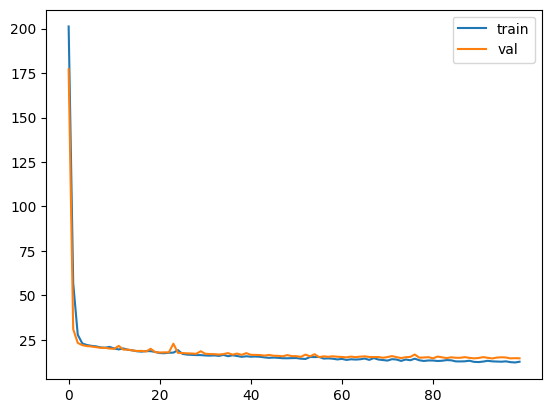

R² Train Score: 0.638
Train RMSE:     ±0.603
Train MAE:      ±0.438
R² Val Score: 0.521
Val RMSE:     ±0.690
Val MAE:      ±0.521


In [26]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xticks(range(0, epochs, 20))
plt.savefig('nn_loss.png')
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

In [ ]:
epochs = 100
model = gnn_edges.GINE(256, 128, 16, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

 76%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████▋                                       | 76/100 [03:49<01:16,  3.17s/it]

In [ ]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xticks(range(0, epochs, 20))
plt.savefig('nn_loss.png')
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)

In [ ]:
epochs = 100
model = gnn_edges.Attention(128, 64, 1).to(device)
model.fit(train_loader, val_loader, device, epochs=epochs)

In [ ]:
plt.plot(model.train_loss, label='train')
plt.plot(model.val_loss, label='val')

plt.legend()
plt.xticks(range(0, epochs, 20))
plt.savefig('nn_loss.png')
plt.show()

model.eval()
model.analysis(train_loader, val_loader, device)